# Learning curves

- [Imbalanced Data: Myths, Mistakes and Modern Solutions](https://www.trainindata.com/p/imbalanced-data-myths-mistakes-solutions-book)

In this notebook, I show how to use learning curves to understand if the data size is big enough.

In short, we can use the LearningCurveDisplay function from sklearn, but this function uses thresholds defined internally, which are not always suitable. 

For some cases, where the probability values are clustered together, we may need to calculate the roc-auc, or the average prediction, or any other metric manually. That requires more work.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import trapezoid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import LearningCurveDisplay, train_test_split

from imblearn.datasets import fetch_datasets

In [2]:
# We work with datasets from imbalanced learn, which are imbalanced.

# load dataset from imbalanced learn
def load_dataset(dataset):
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    return data.data, data.target

## Protein homo

This dataset contains 145751 samples, 74 features and an IR of 111.

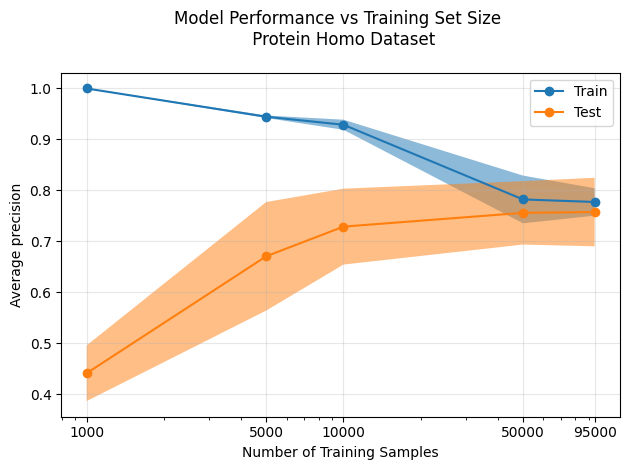

In [4]:
X, y = load_dataset("protein_homo")

model = RandomForestClassifier(max_depth=3, random_state=0)

train_sizes = [1000, 5000, 10000, 50000, 95000]

LearningCurveDisplay.from_estimator(
    model,
    X, y, 
    train_sizes=train_sizes, 
    cv=3,
    scoring='average_precision',
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size \n Protein Homo Dataset', pad=20)
plt.xlabel('Number of Training Samples')
plt.ylabel('Average precision')
plt.xticks(train_sizes, train_sizes)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Pen digits

This dataset contains 10992 samples, 16 features and an IR of 9.4

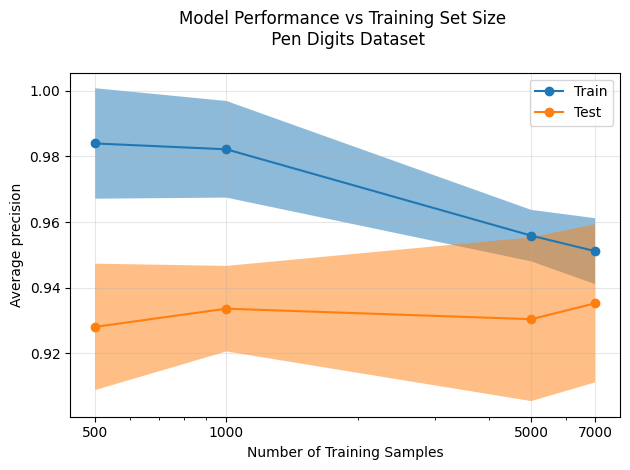

In [5]:
X, y = load_dataset("pen_digits")

model = RandomForestClassifier(max_depth=3, random_state=0)

train_sizes = [500, 1000, 5000, 7000]

LearningCurveDisplay.from_estimator(
    model,
    X, y, 
    train_sizes=train_sizes, 
    cv=3,
    scoring='average_precision',
    line_kw = {"marker": "o"},
)

plt.title('Model Performance vs Training Set Size \n Pen Digits Dataset', pad=20)
plt.xlabel('Number of Training Samples')
plt.ylabel('Average precision')
plt.xticks(train_sizes, train_sizes)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

With LearningCurveDisplay sometimes you get an error, when for example, there are not enough samples of the minority class to evaluate the metric. Sometimes, it helps using bigger data sizes, but not always. When this function does not work, we need to do it manually.

## Website

If we try to create a Learning Curve using sklearn's function for the website dataset it throws an error. That's because the probability values are clustered together, so we need to manually define the thresholds. Those used by sklearn fall outside the value range of probabilities, and then, it does not allow the proper calculation of the roc-auc, or average prediction.

In [6]:
# Train a model
X, y = load_dataset("webpage")

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.3,
  random_state=0,
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

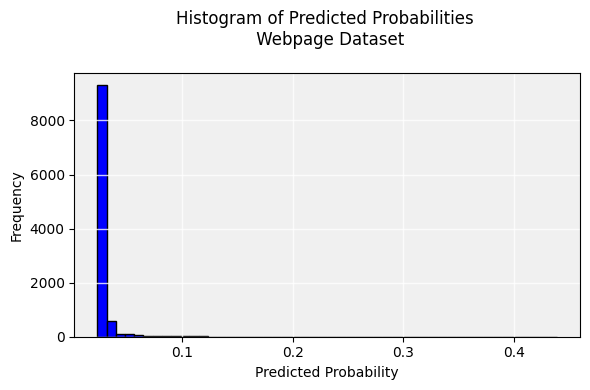

In [7]:
# Plot probability histogram
probs = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(6, 4)) 
plt.hist(probs, bins=50, color='blue', edgecolor='black')
plt.gca().set_facecolor('#f0f0f0')  # lighter grey background
plt.grid(color='white', linestyle='-', linewidth=1, alpha=0.8)  # white grid lines

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Histogram of Predicted Probabilities \n Webpage Dataset", pad=20)
plt.tight_layout()
plt.show()

In [8]:
# Function to calculate the roc-auc based on manually defined thresholds

def calculate_rocauc(probs, ytest, thresholds):    
    tprs = []
    fprs = []
    
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(ytest, preds).ravel()
    
        tpr = tp / (tp + fn)   # sensitivity / recall
        fpr = fp / (fp + tn)   # false positive rate
    
        tprs.append(tpr)
        fprs.append(fpr)
    
    # Sort ROC points by FPR (important before integration)
    fprs, tprs = zip(*sorted(zip(fprs, tprs)))
    
    # Compute custom ROC-AUC using the trapezoidal rule
    roc_auc = trapezoid(tprs, fprs)
    return roc_auc

# test function
thresholds = [0.001, 0.01, 0.02, 0.03, 0.05, 0.1]

calculate_rocauc(probs, y_test, thresholds)

np.float64(0.9053613347992749)

In [9]:
sample_sizes = [1000, 2000, 5000, 10000, 15000, 20000, 25000, 30000]
K = 5   # number of repeated evaluations per size

rocs_train_mean = []
rocs_test_mean = []
rocs_train_std = []
rocs_test_std = []

for n in sample_sizes:
    roc_train_vals = []
    roc_test_vals = []

    for _ in range(K):
        idx = np.random.choice(len(X), size=n, replace=False)

        X_sample = X[idx]
        y_sample = y[idx]

        X_train, X_test, y_train, y_test = train_test_split(
            X_sample, y_sample, test_size=0.3, random_state=None
        )

        model.fit(X_train, y_train)

        probs_train = model.predict_proba(X_train)[:, 1]
        probs_test = model.predict_proba(X_test)[:, 1]

        roc_train = calculate_rocauc(probs_train, y_train, thresholds)
        roc_test = calculate_rocauc(probs_test, y_test, thresholds)

        roc_train_vals.append(roc_train)
        roc_test_vals.append(roc_test)

    # store statistics
    rocs_train_mean.append(np.mean(roc_train_vals))
    rocs_test_mean.append(np.mean(roc_test_vals))
    rocs_train_std.append(np.std(roc_train_vals))
    rocs_test_std.append(np.std(roc_test_vals))

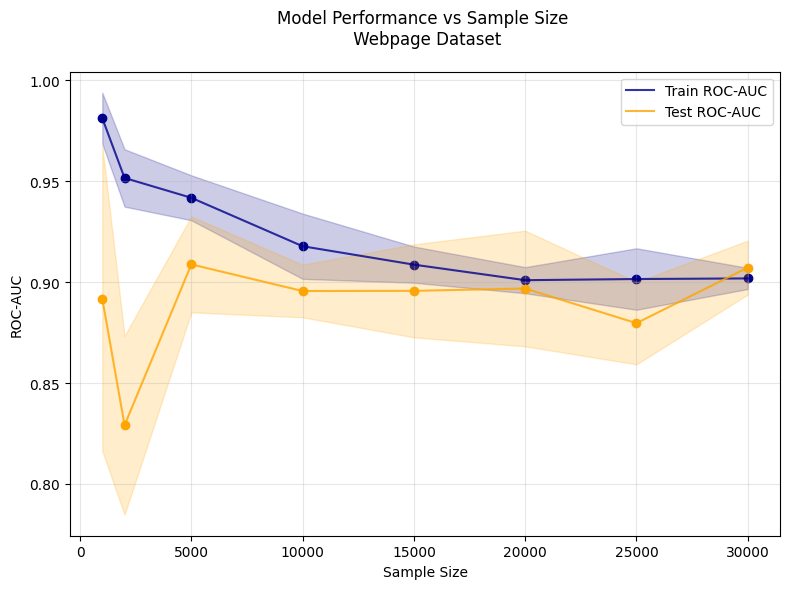

In [10]:
plt.figure(figsize=(8, 6))

# ---- Train ROC-AUC ----
train_color = "darkblue"
plt.plot(sample_sizes, rocs_train_mean, color=train_color, alpha=0.8, label="Train ROC-AUC")
plt.scatter(sample_sizes, rocs_train_mean, color=train_color)
plt.fill_between(
    sample_sizes,
    np.array(rocs_train_mean) - np.array(rocs_train_std),
    np.array(rocs_train_mean) + np.array(rocs_train_std),
    color=train_color,
    alpha=0.2
)

# ---- Test ROC-AUC ----
test_color = "orange"
plt.plot(sample_sizes, rocs_test_mean, color=test_color, alpha=0.8, label="Test ROC-AUC")
plt.scatter(sample_sizes, rocs_test_mean, color=test_color)
plt.fill_between(
    sample_sizes,
    np.array(rocs_test_mean) - np.array(rocs_test_std),
    np.array(rocs_test_mean) + np.array(rocs_test_std),
    color=test_color,
    alpha=0.2
)

plt.xlabel("Sample Size")
plt.ylabel("ROC-AUC")
plt.title("Model Performance vs Sample Size \n Webpage Dataset", pad=20)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
sample_sizes = [1000, 2000, 5000, 10000, 15000, 20000, 25000, 30000]
K = 5   # number of repeated evaluations per size

rocs_train_mean = []
rocs_test_mean = []
rocs_train_std = []
rocs_test_std = []

for n in sample_sizes:
    roc_train_vals = []
    roc_test_vals = []

    # Train model once
    idx = np.random.choice(len(X), size=n, replace=False)
    X_sample = X[idx]
    y_sample = y[idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.3, random_state=None
    )

    model.fit(X_train, y_train)

    # evaluate on bootrstrap of train and test sets
    for _ in range(K):

        idx_train = np.random.choice(len(X_train), size=len(X_train)//2, replace=True)
        idx_test = np.random.choice(len(X_test), size=len(X_test)//2, replace=True)
        
        Xtrain_sample = X_train[idx_train]
        ytrain_sample = y_train[idx_train]

        Xtest_sample = X_test[idx_test]
        ytest_sample = y_test[idx_test]

        probs_train = model.predict_proba(Xtrain_sample)[:, 1]
        probs_test = model.predict_proba(Xtest_sample)[:, 1]

        roc_train = calculate_rocauc(probs_train, ytrain_sample, thresholds)
        roc_test = calculate_rocauc(probs_test, ytest_sample, thresholds)

        roc_train_vals.append(roc_train)
        roc_test_vals.append(roc_test)

    # store statistics
    rocs_train_mean.append(np.mean(roc_train_vals))
    rocs_test_mean.append(np.mean(roc_test_vals))
    rocs_train_std.append(np.std(roc_train_vals))
    rocs_test_std.append(np.std(roc_test_vals))

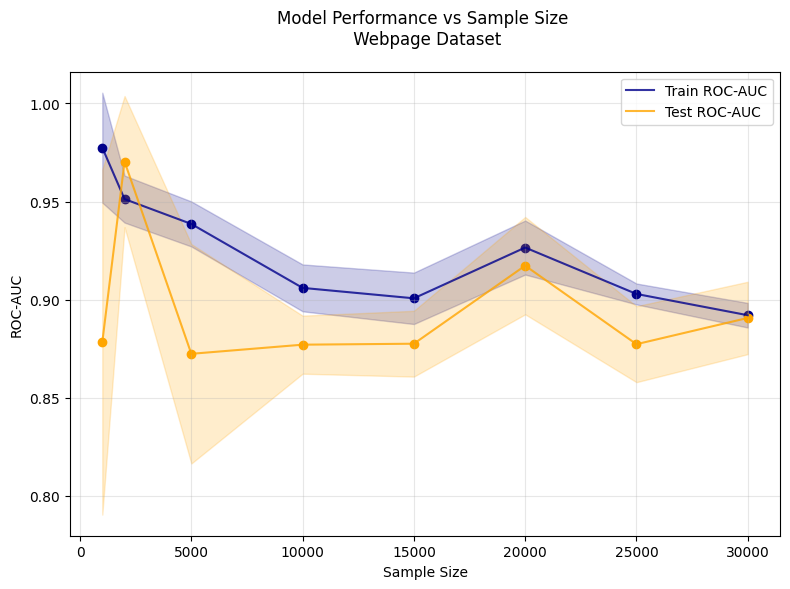

In [12]:
plt.figure(figsize=(8, 6))

# ---- Train ROC-AUC ----
train_color = "darkblue"
plt.plot(sample_sizes, rocs_train_mean, color=train_color, alpha=0.8, label="Train ROC-AUC")
plt.scatter(sample_sizes, rocs_train_mean, color=train_color)
plt.fill_between(
    sample_sizes,
    np.array(rocs_train_mean) - np.array(rocs_train_std),
    np.array(rocs_train_mean) + np.array(rocs_train_std),
    color=train_color,
    alpha=0.2
)

# ---- Test ROC-AUC ----
test_color = "orange"
plt.plot(sample_sizes, rocs_test_mean, color=test_color, alpha=0.8, label="Test ROC-AUC")
plt.scatter(sample_sizes, rocs_test_mean, color=test_color)
plt.fill_between(
    sample_sizes,
    np.array(rocs_test_mean) - np.array(rocs_test_std),
    np.array(rocs_test_mean) + np.array(rocs_test_std),
    color=test_color,
    alpha=0.2
)

plt.xlabel("Sample Size")
plt.ylabel("ROC-AUC")
plt.title("Model Performance vs Sample Size \n Webpage Dataset", pad=20)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()